# ASL Recognition with CNNs

This notebook implements a Convolutional Neural Network (CNN) for recognizing American Sign Language (ASL) gestures. We will compare the performance of a Fully Connected Neural Network (FCNN) with that of a CNN on the ASL dataset.

For more information on the ASL alphabet, you can refer to this site: https://www.asl.gs/

In [1]:
import random

import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [3]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

data_base_path = "./data/" if IN_COLAB else "./data/asl_data/"


### Load data

The data for the ASL dataset is stored in CSV files. It is already split into training, validation, and test sets. Each row in the CSV files contains pixel values for a 28x28 image (flattened into a single row) and a label indicating the ASL gesture.

The labels are integers from 0 to 23, corresponding to the letters A-Z (J and Z are excluded because they require movement).

The images are grayscale, so each pixel value ranges from 0 to 255.

In [4]:
train_df = pd.read_csv(data_base_path + "train.csv")
val_df = pd.read_csv(data_base_path + "val.csv")
test_df = pd.read_csv(data_base_path + "test.csv")

In [5]:
def label_to_letter(lbl):
    letter_code = ord('A') + int(lbl)
    return chr(letter_code) if letter_code < ord('J') else chr(letter_code + 1)

def show(img, lbl):
    i = img.reshape(28,28)
    plt.figure(figsize=(5,5))
    plt.title(label_to_letter(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(i, cmap='gray')

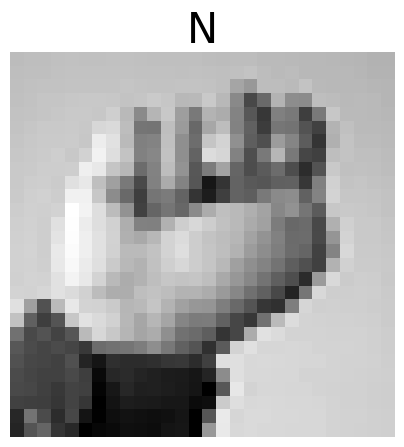

In [6]:
rnd_idx = random.choice(train_df.index)
image = train_df.iloc[rnd_idx].drop('label').values
label = train_df.iloc[rnd_idx]['label']
show(image, label)

## Preparing dataset

Let's start by creating the custom Dataset class for our ASL data. This class will take a DataFrame as input and will return the image and label for each sample. We will also normalize the pixel values to be between 0 and 1. The images will be reshaped as a 28x28 tensor with a single channel (grayscale).

In [7]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1

class AslDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255 # normalize pixel values
        x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT) # tensor dims
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [8]:
train_data = AslDataset(train_df)
val_data = AslDataset(val_df)
test_data = AslDataset(test_df)

In [9]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well. 

In [10]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [11]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [12]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

### Baseline model - fully connected network

Before we implement the CNN, let's train a simple fully connected neural network (FCNN) as a baseline. This will help us understand the performance improvement that the CNN architecture provides for image data.

In [13]:
model_fcnn = nn.Sequential(
    nn.Flatten(),
    nn.Linear(IMG_HEIGHT * IMG_WIDTH, 512),
    nn.ReLU(),
    nn.Dropout(.3),

    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_fcnn = model_fcnn.to(device)

In [14]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_fcnn.parameters())

fcnn_res = train(model_fcnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [02:12<00:00,  6.62s/epoch, train_acc=0.8535, train_loss=0.4273, val_acc=0.7217, val_loss=0.9975]


In [15]:
fcnn_test_loss, fcnn_test_acc = test(model_fcnn, test_loader, loss_function)

### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

In [16]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 28 x 28
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 14 x 14

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 14 x 14
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 7 x 7

    nn.Conv2d(50, 75, 3, stride=1, padding=1),  # 75 x 7 x 7
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_cnn = model_cnn.to(device)

In [17]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [02:04<00:00,  6.22s/epoch, train_acc=0.9980, train_loss=0.0061, val_acc=0.9562, val_loss=0.1784]


In [18]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

## Reflection section

### Which model is better at classifying ASL images?

In [19]:
results_df = pd.DataFrame({
        "test_loss": {"FCNN": fcnn_test_loss, "CNN": cnn_test_loss},
        "test_accuracy": {"FCNN": fcnn_test_acc, "CNN": cnn_test_acc},
    })

display(results_df.style.format({"test_loss": "{:.4f}", "test_accuracy": "{:.4%}"}))

,test_loss,test_accuracy
FCNN,1.0090,72.5878%
CNN,0.1666,95.9565%


Clearly CNN outperformed FCNN by a very large margin both in loss (having almost a third less) and accuracy (10% more). This is likely because CNNs specialize on learning local patterns.

### Which model was _faster_ to train?

FCNN took around 1:45 minutes and CNN took around 2:35 minutes; so definetely FCNN was faster to train

### Plot and compare the learning curves of both models. What do you observe about their training and validation performance over epochs?

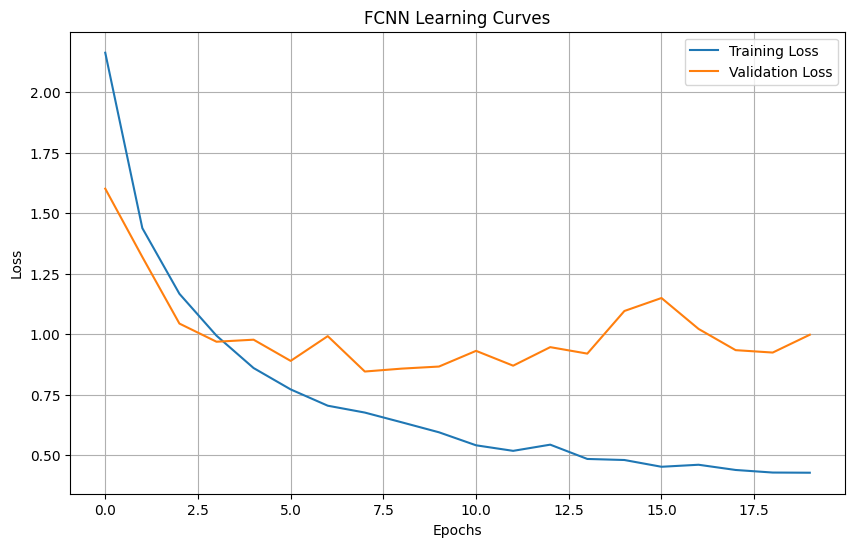

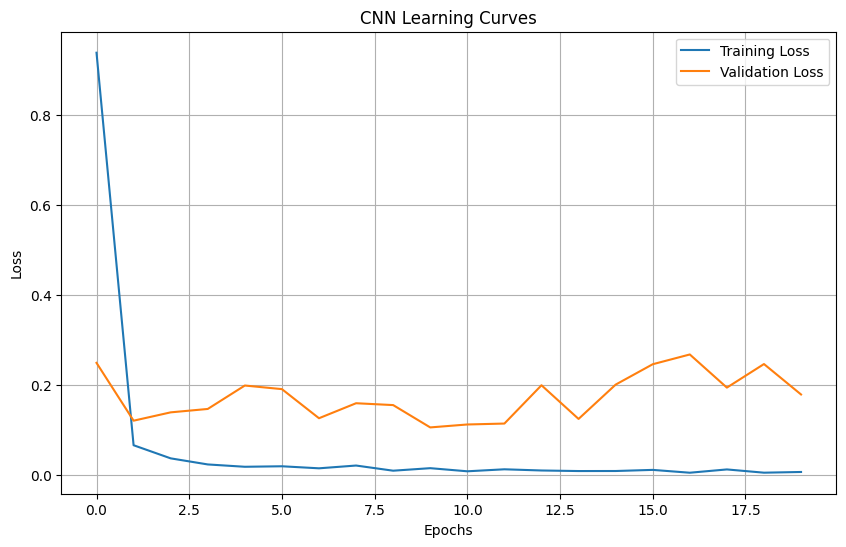

In [20]:
def plot_learning_curves(_train_losses, _val_losses, _title):
    plt.figure(figsize=(10, 6))
    plt.plot(_train_losses, label='Training Loss')
    plt.plot(_val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(_title)
    plt.legend()
    plt.grid()
    plt.show()

plot_learning_curves(fcnn_res['train_loss'], fcnn_res['val_loss'], 'FCNN Learning Curves')
plot_learning_curves(cnn_res['train_loss'], cnn_res['val_loss'], 'CNN Learning Curves')

Both models improve very quickly early on. For FCNN the training loss continuees decreasing but the validation loss oscillates around the 0.75 mark. Meanwhile the CNN drops almost to 0 for the train dataset and oscillates around the 0.2 mark for validation, on later epochs (around 8) the gap between training and validation loss starts to widen which possibly means theres overfitting later on.

### How many trainable parameters does each model have?

Remember that each convolutional layer has $K \times (C_{in} \times k_h \times k_w + 1)$ parameters, where $K$ is the number of filters, $C_{in}$ is the number of input channels, $k_h$ and $k_w$ are the kernel height and width, and the +1 accounts for the bias term.

Each fully connected layer has $N_{in} \times N_{out} + N_{out}$ parameters, where $N_{in}$ is the number of input features and $N_{out}$ is the number of output features.

**FCNN**

In [21]:
nn.Flatten(),
nn.Linear(IMG_HEIGHT * IMG_WIDTH, 512),
nn.Linear(512, 512),
nn.Linear(512, 24)

Linear(in_features=512, out_features=24, bias=True)

Flatten = 784

Linear(IMG_HEIGHT * IMG_WIDTH, 512) 784 x 512 + 512 = 401,090

Linear(512, 512) = 512 x 512 + 512 = 262,656

Linear(512, 24) = 512 x 24 + 24 = 12,312

TOTAL = 401,090 + 262,656 + 12,312 = <u>676,888<u>

**CNN**

In [22]:
nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),
nn.Conv2d(25, 50, 3, stride=1, padding=1),
nn.Conv2d(50, 75, 3, stride=1, padding=1),
nn.Flatten(),
nn.Linear(75 * 3 * 3, 512),
nn.Linear(512, 24)

Linear(in_features=512, out_features=24, bias=True)

Conv2d(IMG_CHANNELS, 25, 3 x 3) = 25 x (1 x 3 x 3 + 1) = 250

Conv2d(25, 50, 3 x 3) = 50 x (25 x 3 x 3 + 1) = 11,300

Conv2d(50, 75, 3 x 3) = 75 x (50 x 3 x 3 + 1) = 33,825

Linear(75 * 3 * 3, 512) = 675 x 512 + 512 = 346,112

Linear(512, 24) = 512 x 24 + 24 = 12,312

TOTAL = 250 + 11,300 + 33,825 + 346,112 + 12,312 = <u>403,799<u>

### How do the models compare in terms of overfitting? Why do you think that is the case?

The scale of the learning curves is a lot smaller for the CNN. There's a much wider gap (around 0.5) between the training and validation curves for FCNN on the later epochs compared to the small 0.3 difference on CNN. This leads me to believe that FCNN is more prone to overfitting

### Final conclusions and remarks

CNN massively outperformed FCNN on this image classification task. It started getting good results much earlier and got much better resutls at the end of training. The downside is that it did take considerably longer to train, but it does use around 200,000 parameters less. In general I do see why CNNs are so powerful, dividing the task of understanding the image into local patterns is a lot easier and more efficient than understanding an image as a whole